# Backtest Your Short-Position Algorithm

In this activity, you’ll backtest an algorithm to determine both the changes to the overall portfolio values and the daily return and cumulative return metrics.

## Instructions:

1. Review the provided code. This includes the `import` statements for the required libraries, the creation of the Pandas DataFrame from the `vnq.csv` file in the `Resources` folder, and the code that creates and visualizes the short-position DMAC trading algorithm.

2. Set an `initial_capital` variable to `100000` to represent the starting value ($100,000) of your simulated portfolio. Be sure to create this variable as a floating point number.

3. Set a `share_size` variable to negative 500 shares (-500).

    > **Note** Remember that you’re using a short-position strategy. The objective is to enter the trade by selling shares at a high price before buying them back, or exiting the trade, at a lower price.

4. Create a new column named “Position” by multiplying the `share_size` value by the values in the “Signal” column.

5. Create a new column named “Entry/Exit Position” by calling the `diff` function on the “Position” column.

6. Create a new column named “Portfolio Holdings” by multiplying the “Close” prices of VNQ by the values in the “Position” column.

7. Create a new column named “Portfolio Cash” by subtracting the cumulative sum of the trades that the “Entry/Exit Position” column indicates from the `initial_capital` value.

8. Create a new column named “Portfolio Total” by adding the values of the “Portfolio Cash” and “Portfolio Holdings” columns.

9. Create a new column named “Portfolio Daily Returns” by calling the `pct_change` function on the “Portfolio Total” column.

10. Create a new column named “Portfolio Cumulative Returns” by calling the `cum_prod` function on the “Portfolio Daily Returns” column.

11. Use the `hvplot` function to plot the short-position DMAC trading strategy against its backtesting results.

12. Review the resulting overlay plot. Then answer the following question: Does it appear that this algorithm suits a short-position trading strategy?




## Step 1: Review the provided code. This includes the `import` statements for the required libraries, the creation of the Pandas DataFrame from the `vnq.csv` file in the `Resources` folder, and the code that creates and visualizes the short-position DMAC trading algorithm.

In [1]:
# Imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Read the CSV file in from the resources folder and create the Pandas DataFrame

In [2]:
# Read the vnq.csv file located in the Resources folder into a Pandas DataFrame
# Set the Date column as the DateTimeIndex
vnq_df = pd.read_csv(
    Path("14.1/02-Create_a_Short_Position_Algorithm/Resources/vnq.csv"),
    index_col="Date",
    parse_dates=True
    
)

# Review the DataFrame
vnq_df.head()

/var/folders/s9/ml6qrgdx03zdn76qyj8422mh0000gn/T/ipykernel_1039/2791971906.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vnq_df = pd.read_csv(


,Open,High,Low,Close,Volume
Date,,,,,
2007-01-03,77.339996,77.709999,76.400002,44.707417,525700
2007-01-04,77.230003,77.260002,76.629997,44.765377,166100
2007-01-05,77.099998,77.099998,75.750000,43.936401,143700
2007-01-08,76.000000,76.000000,75.430000,44.000164,87000
2007-01-09,75.730003,76.959999,75.730003,44.556675,136300


### Generate a Dual Moving Average Crossover Trading Signal

In [3]:
# Filter the Date index and close columns
signals_df = vnq_df.loc[:,['Close']]
signals_df.head()

,Close
Date,
2007-01-03,44.707417
2007-01-04,44.765377
2007-01-05,43.936401
2007-01-08,44.000164
2007-01-09,44.556675


In [7]:
# Set the short window and long window
short_window = 50
long_window = 100

# Generate the short and long moving averages (50 and 100 days, respectively)
signals_df['SMA50'] = signals_df['Close'].rolling(window=short_window).mean()
signals_df['SMA100'] = signals_df['Close'].rolling(window=long_window).mean()
signals_df['Signal'] = 0.0
signals_df.tail()

,Close,SMA50,SMA100,Signal
Date,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0
2009-12-31,30.561541,28.696138,27.789032,0.0


In [14]:
# Generate the trading signal 0 or 1,
# where 1 is when the SMA50 is less than the SMA100
# where 0 is when the SMA50 is greater than than the SMA100
signals_df.iloc[short_window: ,3] = np.where(
    signals_df['SMA50'][short_window: ] < signals_df['SMA100'][short_window: ], 1.0, 0.0

)

signals_df.iloc[95:105,:]


,Close,SMA50,SMA100,Signal
Date,,,,
2007-05-21,43.642437,46.194911,NaN,0.0
2007-05-22,44.289658,46.145049,NaN,0.0
2007-05-23,43.951462,46.110452,NaN,0.0
2007-05-24,43.216797,46.056755,NaN,0.0
2007-05-25,43.461689,45.999724,46.646618,1.0
2007-05-29,45.012638,45.984032,46.649670,1.0
2007-05-30,46.219574,45.983318,46.664212,1.0
2007-05-31,46.033009,45.975163,46.685178,1.0
2007-06-01,46.097130,45.957044,46.706148,1.0


In [15]:
# Calculate the points in time at which a position should be taken, 1 or -1
signals_df['Entry/Exit'] = signals_df['Signal'].diff()
signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit
Date,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0


### Plot Entry and Exit Points of Dual Moving Average Crossover Trading Strategy

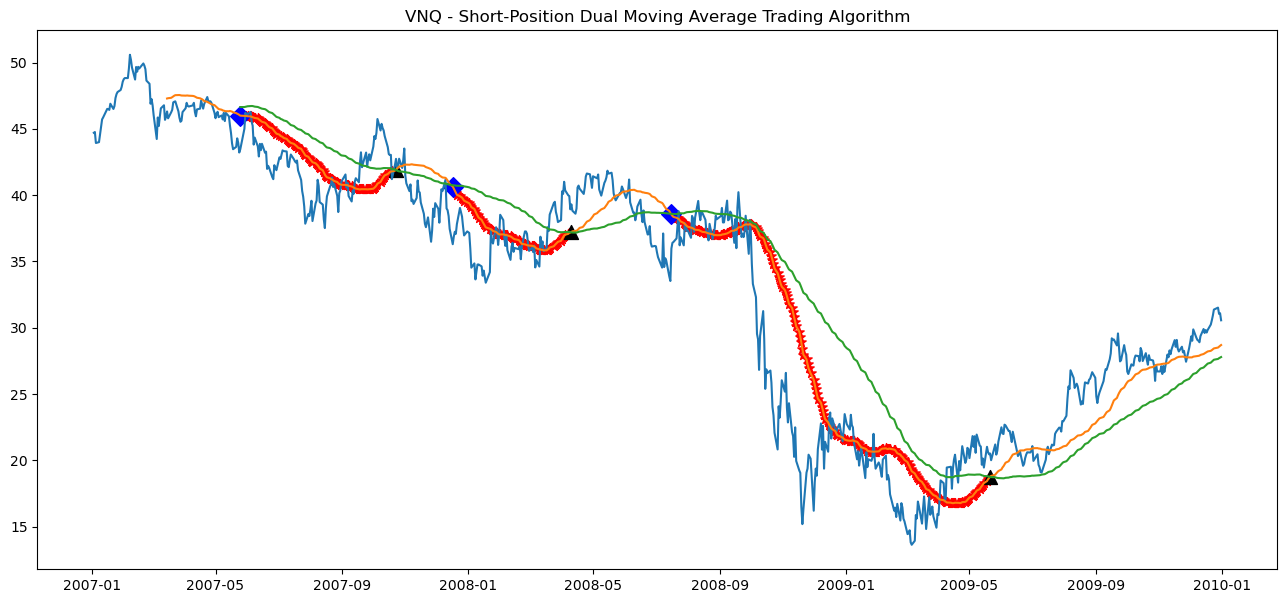

In [32]:
# Visualize entry positions relative to close price
x = signals_df.index
plt.figure(figsize=(16,7))
plt.title("VNQ - Short-Position Dual Moving Average Trading Algorithm")
plt.plot(x,signals_df[['Close','SMA50','SMA100']],label= ['Close','SMA50','SMA100'])
plt.scatter(signals_df[signals_df['Signal'] == 1.0].index, signals_df[signals_df['Signal'] == 1.0]['SMA50'],color='red',marker='*',s=50)
plt.scatter(signals_df[signals_df['Entry/Exit'] == 1.0].index, signals_df[signals_df['Entry/Exit'] == 1.0]['SMA50'],color='blue',marker='D',s=100)
plt.scatter(signals_df[signals_df['Entry/Exit'] == -1.0].index, signals_df[signals_df['Entry/Exit'] == -1.0]['SMA50'],color='black',marker='^',s=100)


plt.show()

## Step 2: Set an `initial_capital` variable to `100000` to represent the starting value (100,000) of your simulated portfolio. Be sure to create this variable as a floating point number.

In [33]:
# Set the initial_capital to 100000
initial_capital = float(100000)
initial_capital

100000.0

## Step 3: Set a `share_size` variable to negative 500 shares (-500).

In [35]:
# Set the share_size to -500
# In a short-position strategy, shares are sold before they are bought 
share_size = -500

## Step 4: Create a new column named “Position” by multiplying the `share_size` value by the values in the “Signal” column.

In [37]:
# Create a column named "Position" by multiplying the share_size by the Signal
# Sell a position (-500 shares) when the dual moving average crossover Signal equals 1 (SMA50 is less than SMA100)
# Buy a position (500 shares) when the dual moving average crossover Signal equals 0 (SMA50 is greater than SMA100)
signals_df["Position"] = share_size * signals_df["Signal"]

signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position
Date,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0


## Step 5: Create a new column named “Entry/Exit Position” by calling the `diff` function on the “Position” column.

In [38]:
# Find the points in time where a 500 share position is bought or sold
signals_df["Entry/Exit Position"] = signals_df["Position"].diff()

# Review the DataFrame
signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position
Date,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0


## Step 6: Create a new column named “Portfolio Holdings” by multiplying the “Close” prices of VNQ by the values in the “Position” column.


In [39]:
# Create a Portfolio Holdings column by multiplying the Close price by the Position
signals_df["Portfolio Holdings"] = signals_df["Close"] * signals_df["Position"]


# Review the DataFrame
signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings
Date,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,-0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,-0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,-0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,-0.0
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,-0.0


## Step 7: Create a new column named “Portfolio Cash” by subtracting the cumulative sum of the trades that the “Entry/Exit Position” column indicates from the `initial_capital` value.

In [40]:
# To calculate Portfolio Cash, subtract the cumulative sum of the trade cost/proceeds from the initial_capital
# The trade cost proceeds are calculated by multiplying the Close price by Entry/Exit Position
signals_df['Portfolio Cash'] = (
    initial_capital - (signals_df['Close']*signals_df['Entry/Exit Position']).cumsum()
)


signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings,Portfolio Cash
Date,,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,-0.0,106587.2295
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,-0.0,106587.2295
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,-0.0,106587.2295
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,-0.0,106587.2295
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,-0.0,106587.2295


## Step 8: Create a new column named “Portfolio Total” by adding the values of the “Portfolio Cash” and “Portfolio Holdings” columns.

In [42]:
# Calculate the Portfolio Total value by adding Portfolio Cash and Portfolio Holdings 
signals_df['Portfolio Total'] = signals_df['Portfolio Cash'] + signals_df['Portfolio Holdings']

signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings,Portfolio Cash,Portfolio Total
Date,,,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295


## Step 9: Create a new column named “Portfolio Daily Returns” by calling the `pct_change` function on the “Portfolio Total” column.

In [43]:
# Calculate the Portfolio Daily Returns based on the Portfolio Total
signals_df["Portfolio Daily Returns"] = signals_df["Portfolio Total"].pct_change()

# Review the DataFrame
signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings,Portfolio Cash,Portfolio Total,Portfolio Daily Returns
Date,,,,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0


## Step 10: Create a new column named “Portfolio Cumulative Returns” by calling the `cum_prod` function on the “Portfolio Daily Returns” column.

In [44]:
# Calculate the Portfolio Cumulative Returns based on the Portfolio Daily Returns
signals_df["Portfolio Cumulative Returns"] = (
    1 + signals_df["Portfolio Daily Returns"]
).cumprod() - 1

# Review the DataFrame
signals_df.tail()

,Close,SMA50,SMA100,Signal,Entry/Exit,Position,Entry/Exit Position,Portfolio Holdings,Portfolio Cash,Portfolio Total,Portfolio Daily Returns,Portfolio Cumulative Returns
Date,,,,,,,,,,,,
2009-12-24,31.367579,28.438977,27.586397,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-28,31.517859,28.504734,27.645874,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-29,31.046522,28.575901,27.702575,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-30,31.094339,28.636155,27.745596,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0,0.065872
2009-12-31,30.561541,28.696138,27.789032,0.0,0.0,-0.0,0.0,-0.0,106587.2295,106587.2295,0.0,0.065872


## Step 11: Use the `hvplot` function to plot the short-position DMAC trading strategy against its backtesting results.

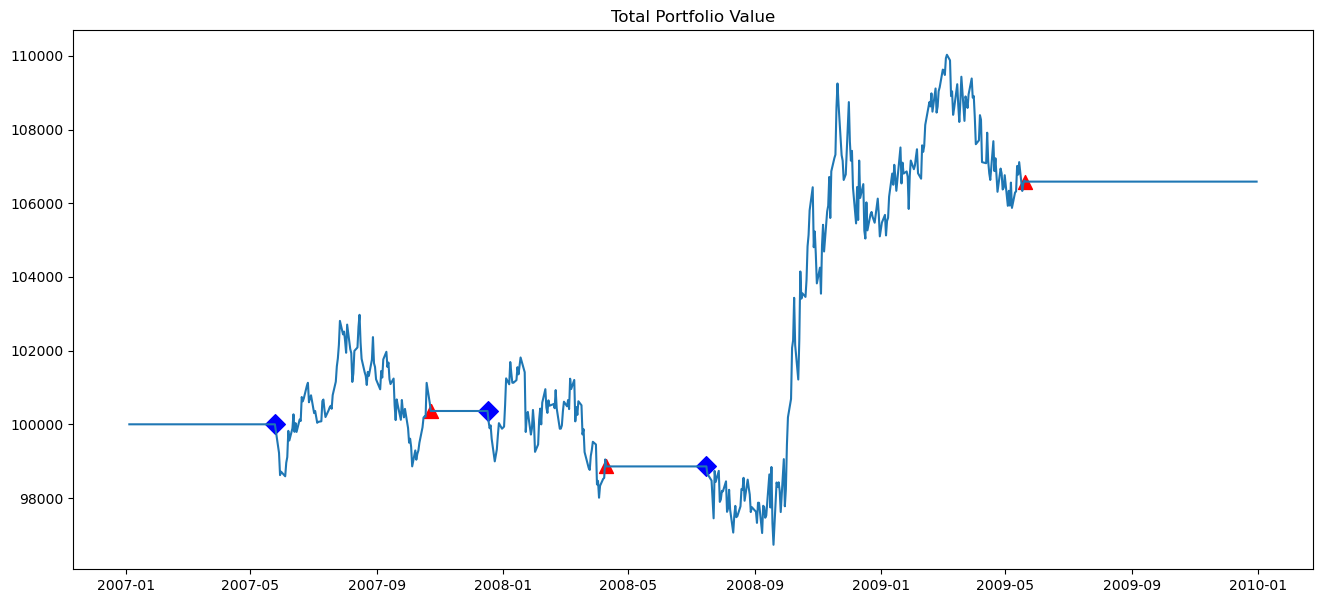

In [51]:
# Visualize the entry positions relative to the Portfolio Total
x = signals_df.index

plt.figure(figsize=(16,7))
plt.title('Total Portfolio Value')
plt.plot(signals_df[["Portfolio Total"]])
plt.scatter(signals_df[signals_df['Entry/Exit'] == 1.0].index, signals_df[signals_df['Entry/Exit'] == 1.0]["Portfolio Total"],color='blue',marker='D',s=100)
plt.scatter(signals_df[signals_df['Entry/Exit'] == -1.0].index, signals_df[signals_df['Entry/Exit'] == -1.0]["Portfolio Total"],color='red',marker='^',s=100)

plt.show()

## Step 12: Answer the following question:

**Question:** Does it appear that this algorithm suits a short-position trading strategy?
    
**Answer:** Although the value of the portfolio did fall below the initial investment of 100,000,  the drop in the stock price in 2008 and 2009 benefited the algorithm's short-position strategy and the portfolio did make money.